In [29]:
### import libraries

# for DL modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

# to read an image from a url
from imageio import imread

# for number-crunching
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

# Import VGG19 and freeze all layers

In [30]:
### import libraries

# for DL modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

# to read an image from a url
from imageio import imread

# for number-crunching
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [31]:
# import the model
vggnet = torchvision.models.vgg19(pretrained=True)

# freeze all layers
for p in vggnet.parameters():
    p.requires_grad = False
  
# set to evaluation mode
vggnet.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [32]:
# send the network to the GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

vggnet.to(device);

# Import two images

In [33]:
img4content = imread('De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg') # https://upload.wikimedia.org/wikipedia/commons/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg
img4style   = imread('Edvard_Munch.jpg') # https://upload.wikimedia.org/wikipedia/commons/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg

# initialize the target image and random numbers
img4target = np.random.randint(low=0,high=255,size=img4content.shape,dtype=np.uint8)

print(img4content.shape)
print(img4target.shape)
print(img4style.shape)

C:\Users\SystemX\AppData\Local\Temp\ipykernel_7192\2895711470.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img4content = imread('De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg') # https://upload.wikimedia.org/wikipedia/commons/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg
C:\Users\SystemX\AppData\Local\Temp\ipykernel_7192\2895711470.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img4style   = imread('Edvard_Munch.jpg') # https://upload.wikimedia.org/wikipedia/commons/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboar

(1675, 3000, 3)
(1675, 3000, 3)
(4000, 3223, 3)


In [34]:
## These images are really large, which will make training take a long time. 

# create the transforms
Ts = T.Compose([ T.ToTensor(),
                 T.Resize(256),
                 T.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
               ])

# apply them to the images ("unsqueeze" to make them a 4D tensor) and push to GPU
img4content = Ts( img4content ).unsqueeze(0).to(device)
img4style   = Ts( img4style   ).unsqueeze(0).to(device)
img4target  = Ts( img4target  ).unsqueeze(0).to(device)

print(img4content.shape)
print(img4target.shape)
print(img4style.shape)

torch.Size([1, 3, 256, 458])
torch.Size([1, 3, 256, 458])
torch.Size([1, 3, 317, 256])


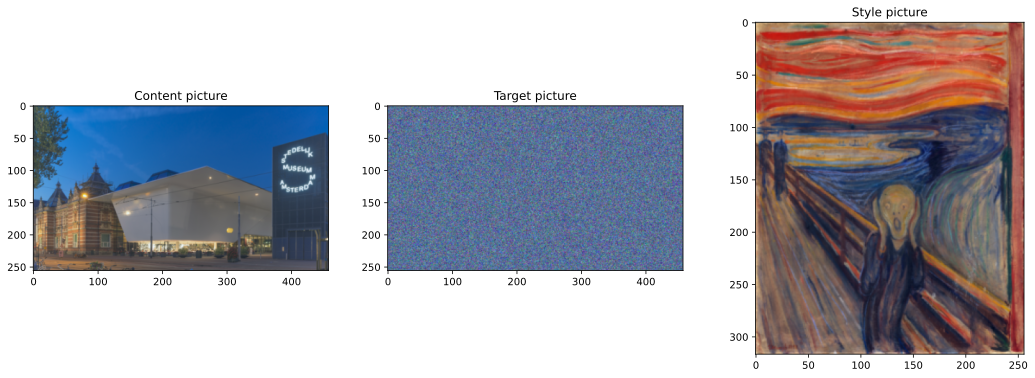

In [35]:
# Let's have a look at the "before" pics
fig,ax = plt.subplots(1,3,figsize=(18,6))

pic = img4content.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[0].imshow(pic)
ax[0].set_title('Content picture')

pic = img4target.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[1].imshow(pic)
ax[1].set_title('Target picture')

pic = img4style.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[2].imshow(pic)
ax[2].set_title('Style picture')

plt.show()

# Functions to extract image feature map activations

In [36]:
# A function that returns feature maps

def getFeatureMapActs(img,net):
  
  # initialize feature maps as a list
  featuremaps = []
  featurenames = []

  convLayerIdx = 0

  # loop through all layers in the "features" block
  for layernum in range(len(net.features)):
    
    # print out info from this layer
    # print(layernum,net.features[layernum])

    # process the image through this layer
    img = net.features[layernum](img)

    # store the image if it's a conv2d layer
    if 'Conv2d' in str(net.features[layernum]):
      featuremaps.append( img )
      featurenames.append( 'ConvLayer_' + str(convLayerIdx) )
      convLayerIdx += 1
  
  return featuremaps,featurenames

In [37]:
# A function that returns the Gram matrix of the feature activation map

def gram_matrix(M):
  
  # reshape to 2D
  _,chans,height,width = M.shape
  M = M.reshape(chans,height*width)  

  # compute and return covariance matrix
  gram = torch.mm(M,M.t()) / (chans*height*width)
  return gram

In [38]:
# inspect the output of the function
featmaps,featnames = getFeatureMapActs(img4content,vggnet)

# print out some info
for i in range(len(featnames)):
  print('Feature map "%s" is size %s'%(featnames[i],(featmaps[i].shape)))

Feature map "ConvLayer_0" is size torch.Size([1, 64, 256, 458])
Feature map "ConvLayer_1" is size torch.Size([1, 64, 256, 458])
Feature map "ConvLayer_2" is size torch.Size([1, 128, 128, 229])
Feature map "ConvLayer_3" is size torch.Size([1, 128, 128, 229])
Feature map "ConvLayer_4" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer_5" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer_6" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer_7" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer_8" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer_9" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer_10" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer_11" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer_12" is size torch.Size([1, 512, 16, 28])
Feature map "ConvLayer_13" is size torch.Size([1, 512, 16, 28])
Feature map "ConvLayer_14" is size torch.Size([1, 512, 16, 28])
Feature map "ConvLayer_15" is size torch

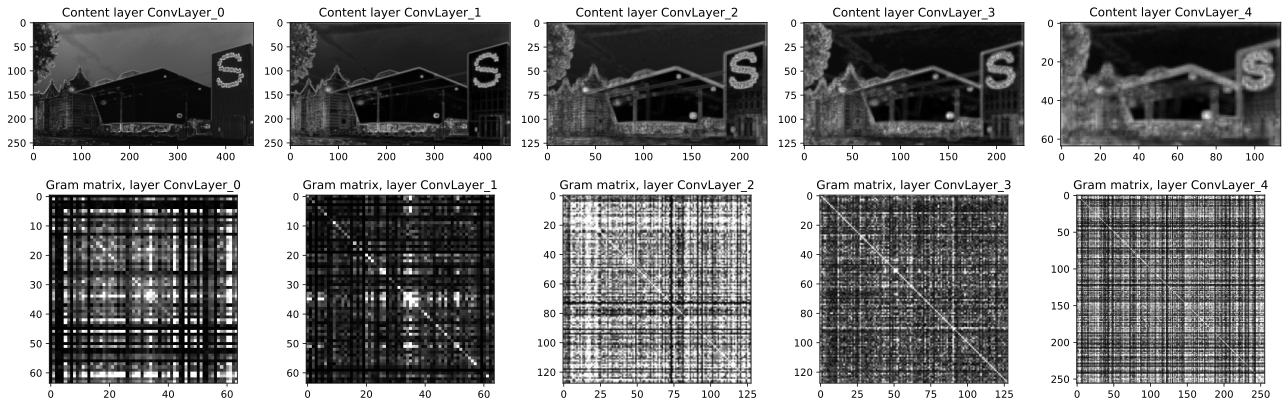

In [39]:
# let's see what the "content" image looks like
contentFeatureMaps,contentFeatureNames = getFeatureMapActs(img4content,vggnet)


fig,axs = plt.subplots(2,5,figsize=(18,6))
for i in range(5):

  # average over all feature maps from this layer, and normalize
  pic = np.mean( contentFeatureMaps[i].cpu().squeeze().numpy() ,axis=0)
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[0,i].imshow(pic,cmap='gray')
  axs[0,i].set_title('Content layer ' + str(contentFeatureNames[i]))


  ### now show the gram matrix
  pic = gram_matrix(contentFeatureMaps[i]).cpu().numpy()
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[1,i].imshow(pic,cmap='gray',vmax=.1)
  axs[1,i].set_title('Gram matrix, layer ' + str(contentFeatureNames[i]))

plt.tight_layout()
plt.show()

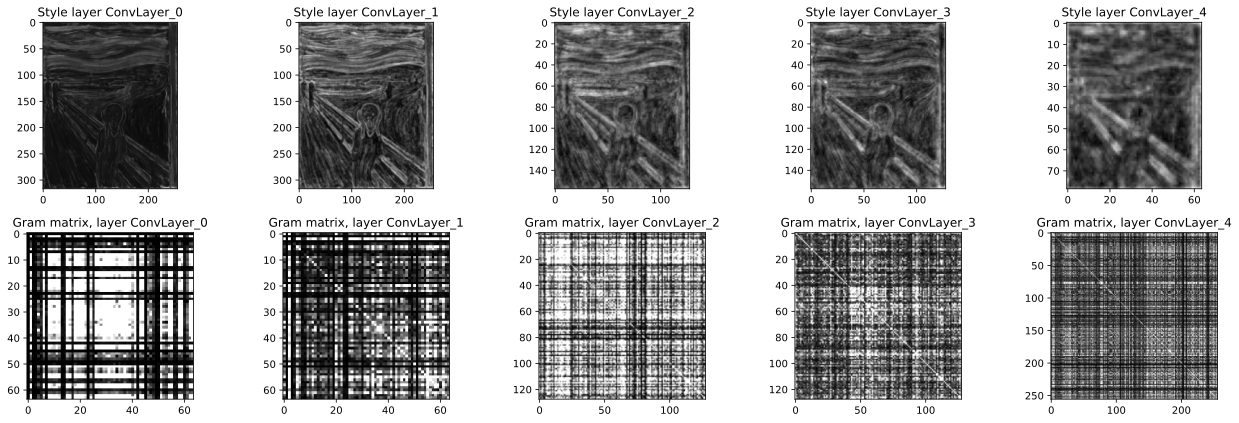

In [40]:

# repeat for the "style" image
styleFeatureMaps,styleFeatureNames = getFeatureMapActs(img4style,vggnet)


fig,axs = plt.subplots(2,5,figsize=(18,6))
for i in range(5):

  # average over all feature maps from this layer, and normalize
  pic = np.mean( styleFeatureMaps[i].cpu().squeeze().numpy() ,axis=0)
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[0,i].imshow(pic,cmap='gray')
  axs[0,i].set_title('Style layer ' + str(styleFeatureNames[i]))


  ### now show the gram matrix
  pic = gram_matrix(styleFeatureMaps[i]).cpu().numpy()
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[1,i].imshow(pic,cmap='gray',vmax=.1)
  axs[1,i].set_title('Gram matrix, layer ' + str(styleFeatureNames[i]))

plt.tight_layout()
plt.show()

# Now for the transfer

In [41]:
# which layers to use
layers4content = [ 'ConvLayer_1','ConvLayer_4' ]
layers4style   = [ 'ConvLayer_1','ConvLayer_2','ConvLayer_3','ConvLayer_4','ConvLayer_5' ]
weights4style  = [      1       ,     .5      ,     .5      ,     .2      ,     .1       ]

In [42]:
# make a copy of the target image and push to GPU
target = img4target.clone()
target.requires_grad = True
target = target.to(device)
styleScaling = 1e6

# number of epochs to train
numepochs = 1500

# optimizer for backprop
optimizer = torch.optim.RMSprop([target],lr=.005)


for epochi in range(numepochs):

  # extract the target feature maps
  targetFeatureMaps,targetFeatureNames = getFeatureMapActs(target,vggnet)


  # initialize the individual loss components
  styleLoss = 0
  contentLoss = 0

  # loop over layers
  for layeri in range(len(targetFeatureNames)):


    # compute the content loss
    if targetFeatureNames[layeri] in layers4content:
      contentLoss += torch.mean( (targetFeatureMaps[layeri]-contentFeatureMaps[layeri])**2 )


    # compute the style loss
    if targetFeatureNames[layeri] in layers4style:
      
      # Gram matrices
      Gtarget = gram_matrix(targetFeatureMaps[layeri])
      Gstyle  = gram_matrix(styleFeatureMaps[layeri])

      # compute their loss (de-weighted with increasing depth)
      styleLoss += torch.mean( (Gtarget-Gstyle)**2 ) * weights4style[layers4style.index(targetFeatureNames[layeri])]

  
  # combined loss
  combiloss = styleScaling*styleLoss + contentLoss

  # finally ready for backprop!
  optimizer.zero_grad()
  combiloss.backward()
  optimizer.step()


# Check the result

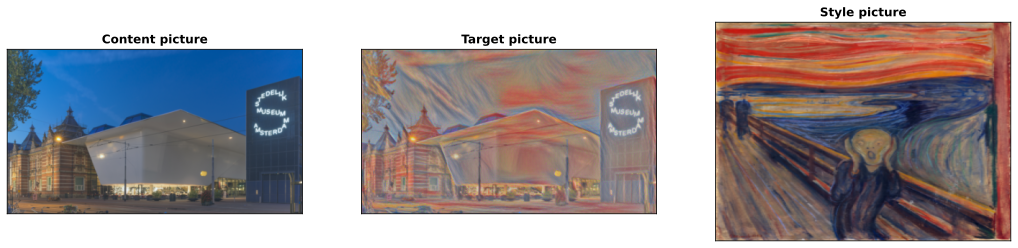

In [43]:
# the "after" pic
fig,ax = plt.subplots(1,3,figsize=(18,11))

pic = img4content.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[0].imshow(pic)
ax[0].set_title('Content picture',fontweight='bold')
ax[0].set_xticks([])
ax[0].set_yticks([])

pic = torch.sigmoid(target).cpu().detach().squeeze().numpy().transpose((1,2,0))
ax[1].imshow(pic)
ax[1].set_title('Target picture',fontweight='bold')
ax[1].set_xticks([])
ax[1].set_yticks([])

pic = img4style.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[2].imshow(pic,aspect=.6)
ax[2].set_title('Style picture',fontweight='bold')
ax[2].set_xticks([])
ax[2].set_yticks([])

plt.show()

# Additional explorations

In [44]:
# 1) The minimization loss has two components (style and content). Modify the code to store these two components in a
#    Nx2 matrix (for N training epochs). Then plot them. This will help you understand and adjust the styleScaling gain
#    factor.
# 
# 2) Change the layers for minimizing losses to content and style images. Do you notice an effect of minimizing the
#    earlier vs. later layers? How about more vs. fewer layers?
# 
# 3) Modify the code to save the target image every, e.g.,
#    100 epochs. Then you can make a series of images showing how the noise transforms into a lovely picture.
# 
# 4) The target picture was initialized as random noise. But it doesn't need to be. It can be initialized to anything
#    else. Try the following target initializations: (1) the content picture; (2) the style picture; (3) a completely
#    different picture (e.g., a picture of you or a cat or the Taj Mahal).
# 

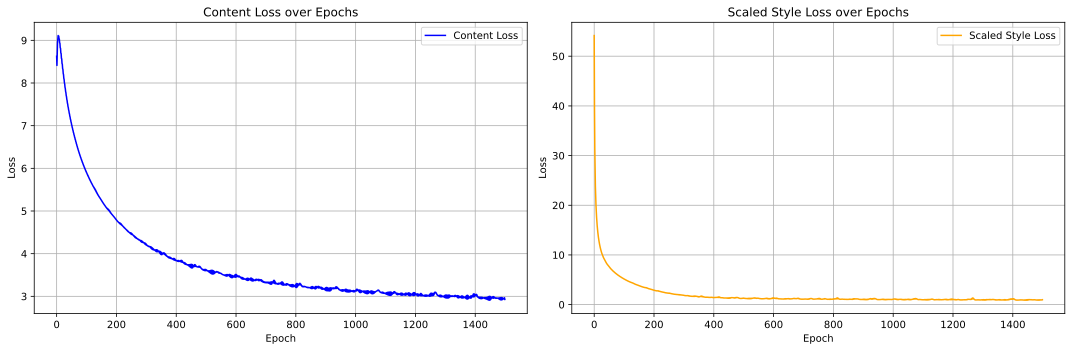

In [ ]:
# make a copy of the target image and push to GPU
target = img4target.clone()
target.requires_grad = True
target = target.to(device)
styleScaling = 1e6

# number of epochs to train
numepochs = 1500

# optimizer for backprop
optimizer = torch.optim.RMSprop([target], lr=.005)

# ДОДАНО: ініціалізація матриці Nx2 для збереження втрат
# Стовпець 0 - Content Loss, Стовпець 1 - Scaled Style Loss
losses = np.zeros((numepochs, 2))

for epochi in range(numepochs):

  # extract the target feature maps
  targetFeatureMaps, targetFeatureNames = getFeatureMapActs(target, vggnet)

  # initialize the individual loss components
  styleLoss = 0
  contentLoss = 0

  # loop over layers
  for layeri in range(len(targetFeatureNames)):

    # compute the content loss
    if targetFeatureNames[layeri] in layers4content:
      contentLoss += torch.mean( (targetFeatureMaps[layeri]-contentFeatureMaps[layeri])**2 )

    # compute the style loss
    if targetFeatureNames[layeri] in layers4style:
      
      # Gram matrices
      Gtarget = gram_matrix(targetFeatureMaps[layeri])
      Gstyle  = gram_matrix(styleFeatureMaps[layeri])

      # compute their loss (de-weighted with increasing depth)
      styleLoss += torch.mean( (Gtarget-Gstyle)**2 ) * weights4style[layers4style.index(targetFeatureNames[layeri])]

  
  # combined loss
  combiloss = styleScaling * styleLoss + contentLoss

  # finally ready for backprop!
  optimizer.zero_grad()
  combiloss.backward()
  optimizer.step()

  losses[epochi, 0] = contentLoss.item()
  losses[epochi, 1] = (styleScaling * styleLoss).item()


# Побудова графіків після завершення навчання
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Графік Content Loss
ax[0].plot(losses[:, 0], label='Content Loss', color='blue')
ax[0].set_title('Content Loss over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True)
ax[0].legend()

# Графік Style Loss
ax[1].plot(losses[:, 1], label='Scaled Style Loss', color='orange')
ax[1].set_title('Scaled Style Loss over Epochs')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

### Експерименти з шарами для оптимізації стилю та контенту (Content and Style Layers)

Починаємо навчання з новими шарами...
Епоха 100/500 | Content Loss: 5.54 | Style Loss: 3.45
Епоха 200/500 | Content Loss: 4.61 | Style Loss: 2.22
Епоха 300/500 | Content Loss: 3.99 | Style Loss: 1.96
Епоха 400/500 | Content Loss: 3.63 | Style Loss: 1.84
Епоха 500/500 | Content Loss: 3.41 | Style Loss: 1.71
Навчання завершено!


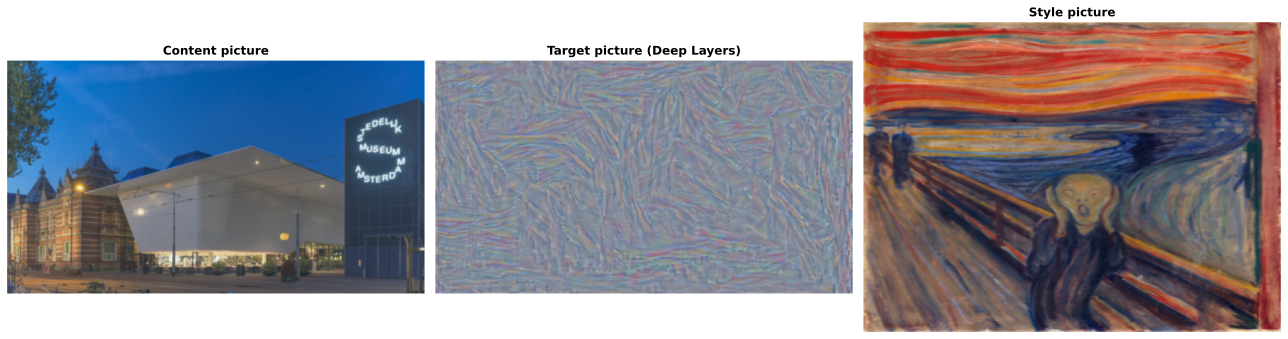

In [46]:
# Експеримент: Фокус на пізніших (глибших) шарах для стилю та контенту
layers4content = [ 'ConvLayer_10' ] 
layers4style   = [ 'ConvLayer_5', 'ConvLayer_8', 'ConvLayer_10', 'ConvLayer_12' ]
weights4style  = [      1       ,       0.8    ,       0.5     ,       0.3      ]

target = img4target.clone()
target.requires_grad = True
target = target.to(device)

styleScaling = 1e6
numepochs = 500 # Зменшив до 500 для швидшого експерименту
optimizer = torch.optim.RMSprop([target], lr=.005)

# Матриця для збереження втрат
losses = np.zeros((numepochs, 2))

print("Починаємо навчання з новими шарами...")

for epochi in range(numepochs):

  # extract the target feature maps
  targetFeatureMaps, targetFeatureNames = getFeatureMapActs(target, vggnet)

  # initialize the individual loss components
  styleLoss = 0
  contentLoss = 0

  # loop over layers
  for layeri in range(len(targetFeatureNames)):

    # compute the content loss
    if targetFeatureNames[layeri] in layers4content:
      contentLoss += torch.mean( (targetFeatureMaps[layeri]-contentFeatureMaps[layeri])**2 )

    # compute the style loss
    if targetFeatureNames[layeri] in layers4style:
      
      # Gram matrices
      Gtarget = gram_matrix(targetFeatureMaps[layeri])
      Gstyle  = gram_matrix(styleFeatureMaps[layeri])

      # compute their loss (de-weighted with increasing depth)
      weight_idx = layers4style.index(targetFeatureNames[layeri])
      styleLoss += torch.mean( (Gtarget-Gstyle)**2 ) * weights4style[weight_idx]

  
  # combined loss
  combiloss = styleScaling * styleLoss + contentLoss

  # finally ready for backprop!
  optimizer.zero_grad()
  combiloss.backward()
  optimizer.step()

  losses[epochi, 0] = contentLoss.item()
  losses[epochi, 1] = (styleScaling * styleLoss).item()

  if (epochi + 1) % 100 == 0:
      print(f"Епоха {epochi+1}/{numepochs} | Content Loss: {contentLoss.item():.2f} | Style Loss: {(styleScaling*styleLoss).item():.2f}")

print("Навчання завершено!")

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

pic = img4content.cpu().squeeze().numpy().transpose((1, 2, 0))
pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
ax[0].imshow(pic)
ax[0].set_title('Content picture', fontweight='bold')
ax[0].axis('off')

# Використовуємо torch.sigmoid для коректного відображення пікселів
pic = torch.sigmoid(target).cpu().detach().squeeze().numpy().transpose((1, 2, 0))
ax[1].imshow(pic)
ax[1].set_title('Target picture (Deep Layers)', fontweight='bold')
ax[1].axis('off')

pic = img4style.cpu().squeeze().numpy().transpose((1, 2, 0))
pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
ax[2].imshow(pic, aspect=.6)
ax[2].set_title('Style picture', fontweight='bold')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Починаємо навчання з РАННІМИ шарами...
Епоха 100/500 | Content Loss: 0.41 | Style Loss: 0.81
Епоха 200/500 | Content Loss: 0.41 | Style Loss: 0.39
Епоха 300/500 | Content Loss: 0.41 | Style Loss: 0.25
Епоха 400/500 | Content Loss: 0.40 | Style Loss: 0.17
Епоха 500/500 | Content Loss: 0.39 | Style Loss: 0.12
Навчання завершено!


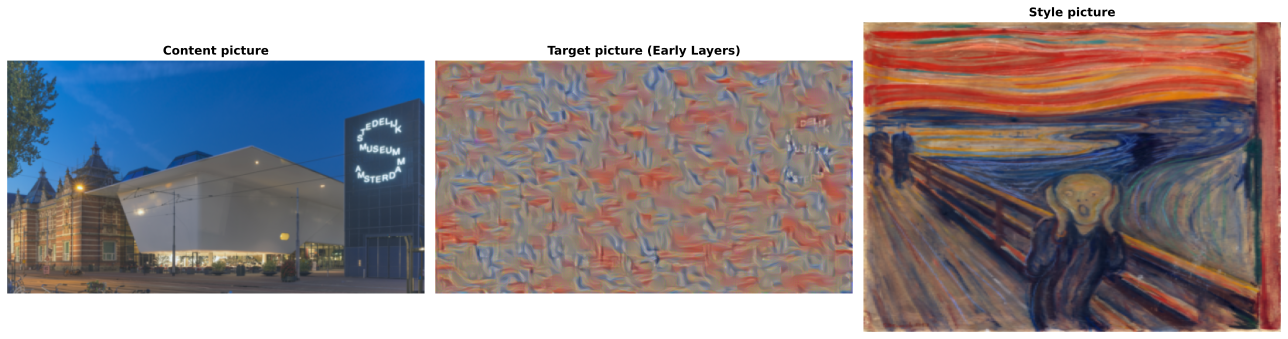

In [47]:
# Експеримент 2. Фокус на ранніх шарах
layers4content = [ 'ConvLayer_0' ] 
layers4style   = [ 'ConvLayer_0', 'ConvLayer_1', 'ConvLayer_2' ]
weights4style  = [      1       ,      0.8     ,      0.5      ]

target = img4target.clone()
target.requires_grad = True
target = target.to(device)

styleScaling = 1e6
numepochs = 500 
optimizer = torch.optim.RMSprop([target], lr=.005)

losses = np.zeros((numepochs, 2))

print("Починаємо навчання з РАННІМИ шарами...")

for epochi in range(numepochs):
  targetFeatureMaps, targetFeatureNames = getFeatureMapActs(target, vggnet)
  styleLoss = 0
  contentLoss = 0

  for layeri in range(len(targetFeatureNames)):
    if targetFeatureNames[layeri] in layers4content:
      contentLoss += torch.mean( (targetFeatureMaps[layeri]-contentFeatureMaps[layeri])**2 )

    if targetFeatureNames[layeri] in layers4style:
      Gtarget = gram_matrix(targetFeatureMaps[layeri])
      Gstyle  = gram_matrix(styleFeatureMaps[layeri])
      weight_idx = layers4style.index(targetFeatureNames[layeri])
      styleLoss += torch.mean( (Gtarget-Gstyle)**2 ) * weights4style[weight_idx]

  combiloss = styleScaling * styleLoss + contentLoss

  optimizer.zero_grad()
  combiloss.backward()
  optimizer.step()

  losses[epochi, 0] = contentLoss.item()
  losses[epochi, 1] = (styleScaling * styleLoss).item()

  if (epochi + 1) % 100 == 0:
      print(f"Епоха {epochi+1}/{numepochs} | Content Loss: {contentLoss.item():.2f} | Style Loss: {(styleScaling*styleLoss).item():.2f}")

print("Навчання завершено!")

# Візуалізація
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

pic = img4content.cpu().squeeze().numpy().transpose((1, 2, 0))
pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
ax[0].imshow(pic)
ax[0].set_title('Content picture', fontweight='bold')
ax[0].axis('off')

pic = torch.sigmoid(target).cpu().detach().squeeze().numpy().transpose((1, 2, 0))
ax[1].imshow(pic)
ax[1].set_title('Target picture (Early Layers)', fontweight='bold')
ax[1].axis('off')

pic = img4style.cpu().squeeze().numpy().transpose((1, 2, 0))
pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
ax[2].imshow(pic, aspect=.6)
ax[2].set_title('Style picture', fontweight='bold')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Починаємо навчання з ініціалізацією стилем...
Епоха 100/500 | Content Loss: 6.20 | Style Loss: 0.73
Епоха 200/500 | Content Loss: 5.18 | Style Loss: 0.83
Епоха 300/500 | Content Loss: 4.62 | Style Loss: 0.73
Епоха 400/500 | Content Loss: 4.25 | Style Loss: 0.77
Епоха 500/500 | Content Loss: 3.98 | Style Loss: 0.76
Навчання завершено!


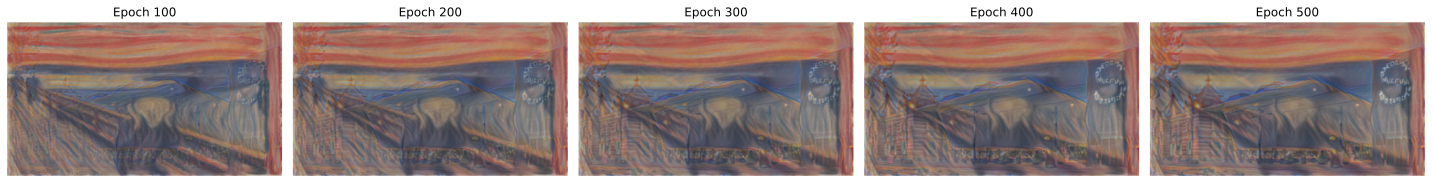

In [49]:
import torch.nn.functional as F

layers4content = [ 'ConvLayer_1','ConvLayer_4' ]
layers4style   = [ 'ConvLayer_1','ConvLayer_2','ConvLayer_3','ConvLayer_4','ConvLayer_5' ]
weights4style  = [      1       ,     .5      ,     .5      ,     .2      ,     .1       ]

# 4) Зміна ініціалізації
# Ініціалізація стилем
target = F.interpolate(img4style, size=(img4content.shape[2], img4content.shape[3]), mode='bilinear').clone()

target.requires_grad = True
target = target.to(device)

styleScaling = 1e6
numepochs = 500
optimizer = torch.optim.RMSprop([target], lr=.005)

#  3) Список для збереження еволюції
saved_images = []

print("Починаємо навчання з ініціалізацією стилем...")

for epochi in range(numepochs):
  targetFeatureMaps, targetFeatureNames = getFeatureMapActs(target, vggnet)
  styleLoss = 0
  contentLoss = 0

  for layeri in range(len(targetFeatureNames)):
    if targetFeatureNames[layeri] in layers4content:
      contentLoss += torch.mean( (targetFeatureMaps[layeri]-contentFeatureMaps[layeri])**2 )

    if targetFeatureNames[layeri] in layers4style:
      Gtarget = gram_matrix(targetFeatureMaps[layeri])
      Gstyle  = gram_matrix(styleFeatureMaps[layeri])
      weight_idx = layers4style.index(targetFeatureNames[layeri])
      styleLoss += torch.mean( (Gtarget-Gstyle)**2 ) * weights4style[weight_idx]

  combiloss = styleScaling * styleLoss + contentLoss

  optimizer.zero_grad()
  combiloss.backward()
  optimizer.step()

  # 3) Зберігаємо картинку кожні 100 епох 
  if (epochi + 1) % 100 == 0:
      print(f"Епоха {epochi+1}/{numepochs} | Content Loss: {contentLoss.item():.2f} | Style Loss: {(styleScaling*styleLoss).item():.2f}")
      
      # Перетворюємо тензор у формат для відображення і зберігаємо в список
      current_pic = torch.sigmoid(target).cpu().detach().squeeze().numpy().transpose((1, 2, 0))
      saved_images.append(current_pic)

print("Навчання завершено!")

#  3) візуалізація еволюції
num_saved = len(saved_images)
fig, axes = plt.subplots(1, num_saved, figsize=(4 * num_saved, 4))

for i, pic in enumerate(saved_images):
    axes[i].imshow(pic)
    axes[i].set_title(f'Epoch {(i+1)*100}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Висновки до практичної роботи з Neural Style Transfer (NST)

У ході виконання цієї практичної роботи ми дослідили ключові аспекти роботи алгоритму переносу стилю на базі згорткової нейромережі VGG19. На основі проведених експериментів можна зробити наступні висновки:

**1. Балансування функції втрат (Завдання 1)**
Розділення та візуалізація `Content Loss` та `Style Loss` у вигляді графіків довели, що процес оптимізації потребує ретельного налаштування коефіцієнта `styleScaling`. Оскільки ці дві метрики мають різний масштаб, без правильного балансування мережа буде ігнорувати або структуру оригінального зображення, або стиль художника.

**2. Вплив глибини шарів на генерацію**
Вибір шарів VGG19 для вилучення ознак кардинально змінює результат:
*   **Ранні шари (Early Layers):** Захоплюють лише базові візуальні елементи (кольори, мікро-текстури, градієнти). При їх використанні цільове зображення зберігає ідеальну структуру (як на фотографії), але стиль переноситься дуже слабко — лише на рівні піксельного "шуму" чи колірного фільтра.
*   **Пізні шари (Deep Layers):** Захоплюють високорівневі абстрактні концепції, великі форми та "настрій" картини. У цьому випадку стиль переноситься дуже агресивно (великі мазки, завихрення), але мережа втрачає розуміння точної геометрії та піксельної структури оригінального об'єкта. 
*   **Висновок:** Для отримання естетичного результату необхідно комбінувати шари різної глибини, щоб мережа бачила як дрібні деталі пензля, так і загальну композицію.

**3. Еволюція та початкова ініціалізація**
*   Ініціалізація цільового тензора випадковим шумом працює, але потребує значно більшої кількості епох для формування осмисленого зображення.
*   Ініціалізація **зображенням стилю** (картиною Мунка) створила цікавий ефект зворотної оптимізації: оскільки `Style Loss` від самого початку був низьким, нейромережа сфокусувалася на мінімізації `Content Loss`. 
*   Збереження проміжних результатів кожні 100 епох наочно продемонструвало цей процес: ми змогли поспостерігати, як контури музею поступово "проступали" та формувалися крізь абстрактне полотно художника за допомогою алгоритму градієнтного спуску.